In [137]:
import pandas as pd
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, f1_score, recall_score,precision_score, confusion_matrix, classification_report,roc_auc_score, roc_curve
from scipy.stats import skew

from sklearn.impute import KNNImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 1) Problem Statement ==========================================

In [138]:
# 1.age : above 18
    
# 2.sex : male or female 

# 3.cp :Constrictive pericarditis (CP) is a form of diastolic heart failure that
#       arises because an inelastic pericardium inhibits cardiac filling. 
    
# 4.trestbps :resting blood pressure (in mm Hg on admission to the hospital)
    
# 5.chol :serum cholestoral in mg/dl
    
# 6.fbs :fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
    
# 7.restecg :resting electrocardiographic results (0 = normal; 1 = having ST-T; 2 = hypertrophy)
    
# 8.thalach :maximum heart rate achieved
    
# 9.exang : exercise induced angina (1 = yes; 0 = no)
    
# 10.oldpeak: ST depression induced by exercise relative to rest
    
# 11.slope : ST/heart rate slope ( slope)
    
# 12.ca : calcium is present, the higher the score, the higher your risk of heart disease
    
# 13.thal :People with thalassemia can get too much iron in their bodies, either from the 
#     disease or from frequent blood transfusions. Too much iron can result in damage to
#     your heart, liver and endocrine system.

# 2) Data Gathering =============================================

In [139]:
Train_Models_list = []
Test_Models_list = []

Train_recall_score_list = []
Test_recall_score_list = []

Train_precision_score_list = []
Test_precision_score_list = []

Train_f1_score_list = []
Test_f1_score_list = []

Train_accuracy_score_list = []
Test_accuracy_score_list = []

In [140]:
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [141]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [142]:
x = df.drop('target', axis = 1)
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=42, stratify=y)

In [143]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 19 to 110
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       242 non-null    int64  
 1   sex       242 non-null    int64  
 2   cp        242 non-null    int64  
 3   trestbps  242 non-null    int64  
 4   chol      242 non-null    int64  
 5   fbs       242 non-null    int64  
 6   restecg   242 non-null    int64  
 7   thalach   242 non-null    int64  
 8   exang     242 non-null    int64  
 9   oldpeak   242 non-null    float64
 10  slope     242 non-null    int64  
 11  ca        242 non-null    int64  
 12  thal      242 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 26.5 KB


# 3) EDA of Traning data ==========================================

#### 1) age

<Axes: xlabel='age', ylabel='Density'>

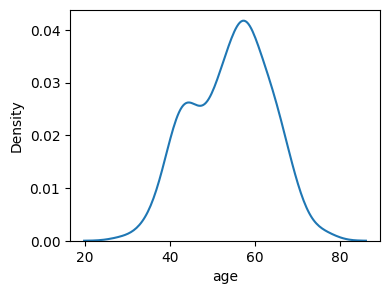

In [144]:
plt.figure(figsize= (4,3))
sns.kdeplot(x_train['age'])

<Axes: xlabel='age'>

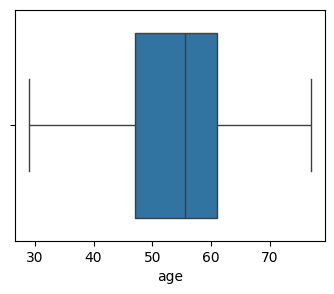

In [145]:
plt.figure(figsize= (4,3))
sns.boxplot(x = x_train['age'])

In [146]:
q1 = x_train['age'].quantile(0.25)
q3 = x_train['age'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 14.0
Lower Tail : 23.2
Upper Tail : 84.8


In [147]:
x_train[x_train['age'] > upper_tail]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal


In [148]:
skew(x_train['age'])

np.float64(-0.15873859129411683)

#### 2) sex

In [149]:
x_train['sex'].value_counts().to_dict()

{1: 165, 0: 77}

#### 3) cp

<Axes: xlabel='cp', ylabel='Density'>

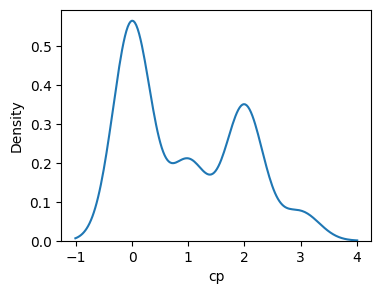

In [150]:
plt.figure(figsize= (4,3))
sns.kdeplot(x_train['cp'])

<Axes: xlabel='cp'>

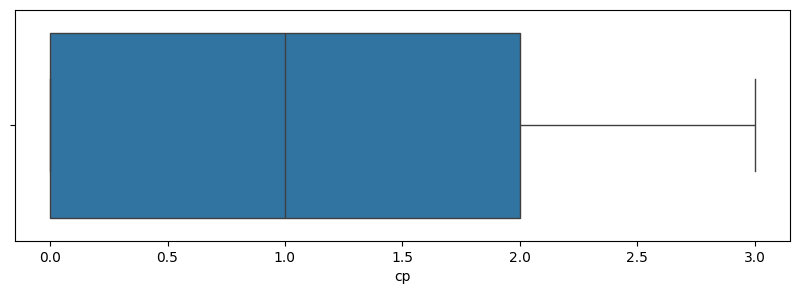

In [151]:
plt.figure(figsize= (10,3))
sns.boxplot(x = x_train['cp'])

In [152]:
skew(x_train['cp'])

np.float64(0.48055142872127193)

#### 4) trestbps

<Axes: xlabel='trestbps', ylabel='Density'>

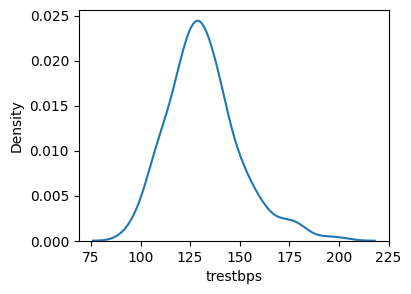

In [153]:
plt.figure(figsize = (4, 3))
sns.kdeplot(x_train['trestbps'])

<Axes: xlabel='trestbps'>

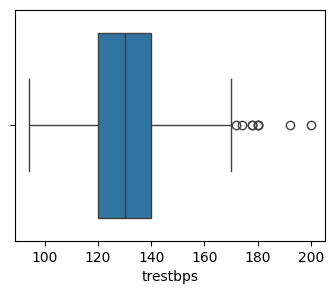

In [154]:
plt.figure(figsize = (4, 3))
sns.boxplot(x= x_train['trestbps'])

In [155]:
q1 = x_train['trestbps'].quantile(0.25)
q3 = x_train['trestbps'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 20.0
Lower Tail : 86.0
Upper Tail : 174.0


In [156]:
x_train.loc[x_train['trestbps'] > upper_tail, 'trestbps'] = upper_tail

<Axes: xlabel='trestbps', ylabel='Density'>

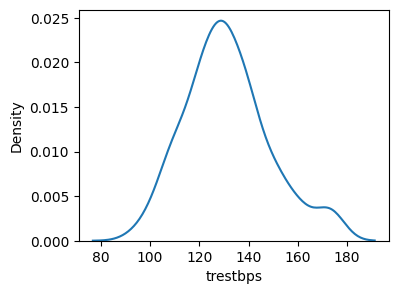

In [157]:
plt.figure(figsize = (4, 3))
sns.kdeplot(x_train['trestbps'])

<Axes: xlabel='trestbps'>

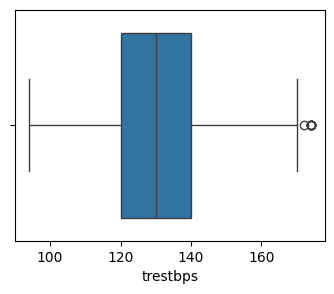

In [158]:
plt.figure(figsize = (4, 3))
sns.boxplot(x= x_train['trestbps'])

In [159]:
skew(x_train['trestbps'])

np.float64(0.4955739105298692)

#### 5) chol

<Axes: xlabel='chol', ylabel='Density'>

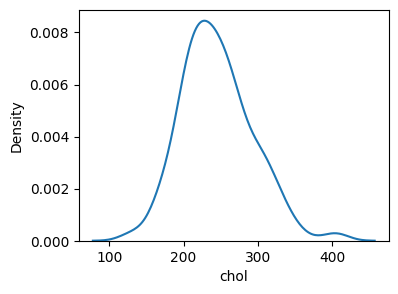

In [160]:
plt.figure(figsize= (4, 3))
sns.kdeplot(x_train['chol'])

<Axes: xlabel='chol'>

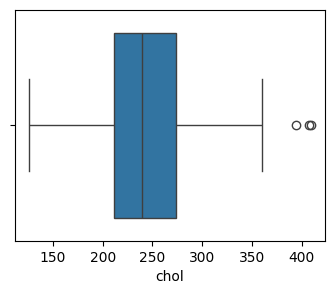

In [161]:
plt.figure(figsize= (4, 3))
sns.boxplot(x =x_train['chol'])

In [162]:
q1 = x_train['chol'].quantile(0.25)
q3 = x_train['chol'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 62.5
Lower Tail : 105.0
Upper Tail : 380.0


In [163]:
x_train.loc[x_train['chol'] > upper_tail, 'chol'] = upper_tail

<Axes: xlabel='chol', ylabel='Density'>

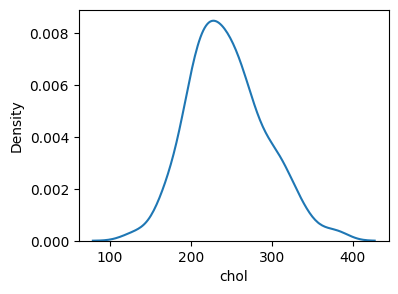

In [164]:
plt.figure(figsize= (4, 3))
sns.kdeplot(x_train['chol'])

<Axes: xlabel='chol'>

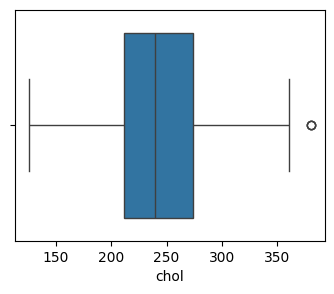

In [165]:
plt.figure(figsize= (4, 3))
sns.boxplot(x =x_train['chol'])

In [166]:
skew(x_train['chol'])

np.float64(0.3887841967307062)

#### 6) fbs

<Axes: xlabel='fbs', ylabel='Density'>

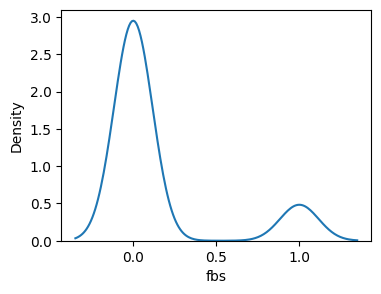

In [167]:
plt.figure(figsize = (4, 3))
sns.kdeplot(x_train['fbs'])

#### 7) thalach

<Axes: xlabel='thalach', ylabel='Density'>

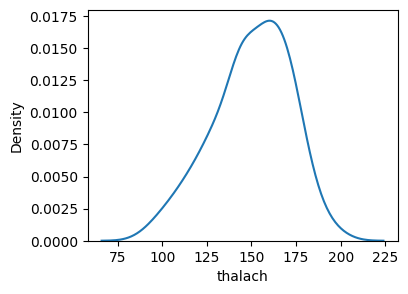

In [168]:
plt.figure(figsize= (4, 3))
sns.kdeplot(x_train['thalach'])

<Axes: xlabel='thalach'>

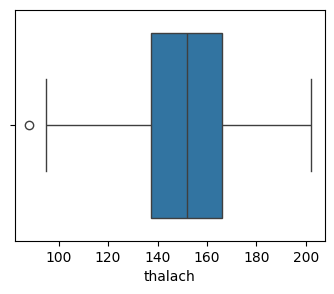

In [169]:
plt.figure(figsize= (4, 3))
sns.boxplot(x = x_train['thalach'])

In [170]:
q1 = x_train['thalach'].quantile(0.25)
q3 = x_train['thalach'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 28.75
Lower Tail : 88.375
Upper Tail : 214.875


In [171]:
x_train.loc[x_train['thalach'] < lower_tail]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
243,57,1,0,152,274,0,1,88,1,1.2,1,1,3


In [172]:
skew(x_train['thalach'])

np.float64(-0.4142280137556616)

#### 8) oldpeak

<Axes: xlabel='oldpeak', ylabel='Density'>

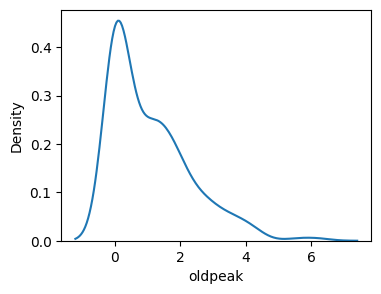

In [173]:
plt.figure(figsize= (4, 3))
sns.kdeplot(x_train['oldpeak'])

<Axes: xlabel='oldpeak'>

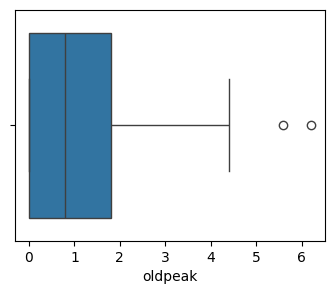

In [174]:
plt.figure(figsize= (4, 3))
sns.boxplot(x = x_train['oldpeak'])

In [175]:
q1 = x_train['oldpeak'].quantile(0.25)
q3 = x_train['oldpeak'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 1.8
Lower Tail : -3.06
Upper Tail : 4.86


In [176]:
x_train.loc[x_train['oldpeak'] > upper_tail, 'oldpeak'] = upper_tail

<Axes: xlabel='oldpeak', ylabel='Density'>

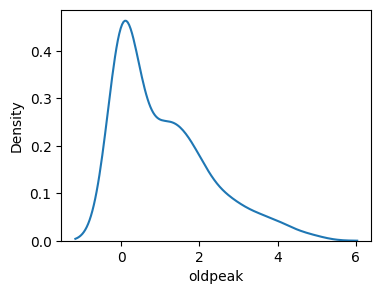

In [177]:
plt.figure(figsize= (4, 3))
sns.kdeplot(x_train['oldpeak'])

<Axes: xlabel='oldpeak'>

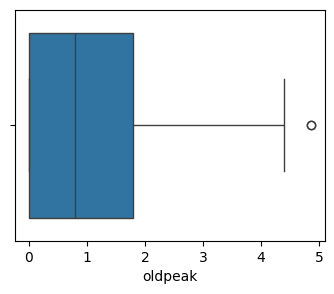

In [178]:
plt.figure(figsize= (4, 3))
sns.boxplot(x = x_train['oldpeak'])

In [179]:
skew(x_train['oldpeak'])

np.float64(1.0713424915913181)

#### 9) slope

In [180]:
x_train['slope'].value_counts()

slope
2    117
1    108
0     17
Name: count, dtype: int64

#### 10) ca

In [181]:
x_train['ca'].value_counts()

ca
0    138
1     55
2     27
3     17
4      5
Name: count, dtype: int64

#### 11) thal

In [182]:
x_train['thal'].value_counts()

thal
2    129
3     98
1     14
0      1
Name: count, dtype: int64

## EDA of testing data =======================================================

#### 4) trestbps

In [183]:
q1 = x_test['trestbps'].quantile(0.25)
q3 = x_test['trestbps'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 20.0
Lower Tail : 86.0
Upper Tail : 174.0


<Axes: xlabel='trestbps'>

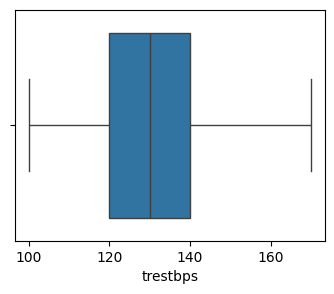

In [184]:
plt.figure(figsize= (4, 3))
sns.boxplot(x= x_test['trestbps'])

In [185]:
x_test.loc[x_test['trestbps'] > upper_tail]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal


#### 5) chol

<Axes: xlabel='chol', ylabel='Density'>

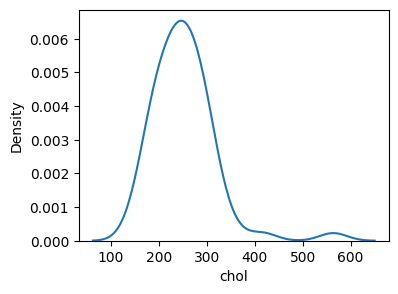

In [186]:
plt.figure(figsize=(4, 3))
sns.kdeplot(x_test['chol'])

In [187]:
q1 = x_test['chol'].quantile(0.25)
q3 = x_test['chol'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 77.0
Lower Tail : 75.1
Upper Tail : 413.9


In [188]:
x_test.loc[x_test['chol'] > upper_tail, 'chol'] = upper_tail

#### 7) thalach

<Axes: xlabel='thalach', ylabel='Density'>

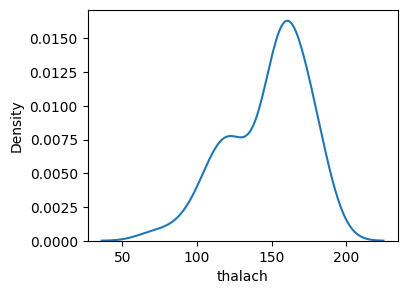

In [189]:
plt.figure(figsize= (4, 3))
sns.kdeplot(x_test['thalach'])

<Axes: xlabel='thalach'>

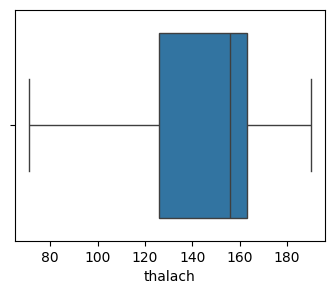

In [190]:
plt.figure(figsize= (4, 3))
sns.boxplot(x= x_test['thalach'])

In [191]:
q1 = x_test['thalach'].quantile(0.25)
q3 = x_test['thalach'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 37.0
Lower Tail : 63.1
Upper Tail : 225.9


In [192]:
x_test.loc[x_test['thalach'] > upper_tail, 'thalach']

Series([], Name: thalach, dtype: int64)

#### 9) oldpeak

<Axes: xlabel='oldpeak', ylabel='Density'>

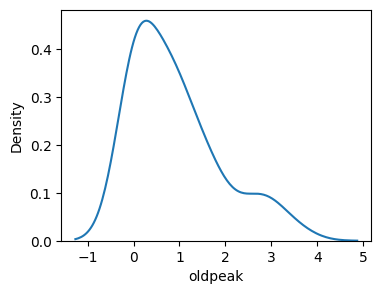

In [193]:
plt.figure(figsize = (4, 3))
sns.kdeplot(x_test['oldpeak'])

<Axes: xlabel='oldpeak'>

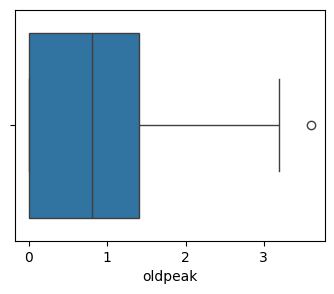

In [194]:
plt.figure(figsize = (4, 3))
sns.boxplot(x = x_test['oldpeak'])

In [195]:
q1 = x_test['oldpeak'].quantile(0.25)
q3 = x_test['oldpeak'].quantile(0.75)
iqr = q3 - q1
print("IQR :",iqr)
lower_tail = q1 - 1.7 * iqr
print("Lower Tail :",lower_tail)

upper_tail = q3 + 1.7 * iqr
print("Upper Tail :",upper_tail)

IQR : 1.4
Lower Tail : -2.38
Upper Tail : 3.78


In [196]:
x_test.loc[x_test['oldpeak'] > upper_tail, 'oldpeak'] = upper_tail

In [197]:
skew(x_test['oldpeak'])

np.float64(1.0578428456329987)

# 6) Model Training =============================================

# 1) LOGISTRIC REGRESSION 


### Evalution of Training Data

In [198]:
logistic_reg = LogisticRegression()
logistic_reg.fit(x_train, y_train)

LogisticRegression()

In [199]:
x_train.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [200]:
y_pred_train_logistic = logistic_reg.predict(x_train)
Train_Models_list.append('Logistic_Reg_train')

log_conf_matrix_train = confusion_matrix(y_train, y_pred_train_logistic)
print("Confusion_matrix :\n", log_conf_matrix_train)
print("*"*50)

log_precision_score_train = precision_score(y_train, y_pred_train_logistic)
print("Precision_score :", log_precision_score_train)
Train_precision_score_list.append(np.around(log_precision_score_train, 3))
print("*"*50)

log_accuracy_score_train = accuracy_score(y_train, y_pred_train_logistic)
print("Accuracy_score :", log_accuracy_score_train)
Train_accuracy_score_list.append(np.around(log_accuracy_score_train, 3))
print("*"*50)

log_f1_score_train = f1_score(y_train, y_pred_train_logistic)
print("F1_score :", log_f1_score_train)
Train_f1_score_list.append(np.around(log_f1_score_train, 3))
print("*"*50)

log_recall_score_train = recall_score(y_train, y_pred_train_logistic)
print("Recall_score :", log_recall_score_train)
Train_recall_score_list.append(np.around(log_recall_score_train, 3))
print("*"*50)

log_clf_report_train = classification_report(y_train, y_pred_train_logistic)
print("Confusion_matrix :\n", log_clf_report_train)
print("*"*50)

Confusion_matrix :
 [[ 84  26]
 [ 12 120]]
**************************************************
Precision_score : 0.821917808219178
**************************************************
Accuracy_score : 0.8429752066115702
**************************************************
F1_score : 0.8633093525179856
**************************************************
Recall_score : 0.9090909090909091
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.88      0.76      0.82       110
           1       0.82      0.91      0.86       132

    accuracy                           0.84       242
   macro avg       0.85      0.84      0.84       242
weighted avg       0.85      0.84      0.84       242

**************************************************


### Evaluation of Testing Data

In [201]:
y_pred_test_logistic = logistic_reg.predict(x_test)
Test_Models_list.append("Logistic_Reg_Test")

log_conf_matrix_test = confusion_matrix(y_test, y_pred_test_logistic)
print("Confusion_matrix :\n", log_conf_matrix_test)
print("*"*50)

log_precision_score_test = precision_score(y_test, y_pred_test_logistic)
print("Precision_score :", log_precision_score_test)
Test_precision_score_list.append(np.around(log_precision_score_test, 3))
print("*"*50)

log_accuracy_score_test = accuracy_score(y_test, y_pred_test_logistic)
print("Accuracy_score :", log_accuracy_score_test)
Test_accuracy_score_list.append(np.around(log_accuracy_score_test, 3))
print("*"*50)

log_f1_score_test = f1_score(y_test, y_pred_test_logistic)
print("F1_score :", log_f1_score_test)
Test_f1_score_list.append(np.around(log_f1_score_test, 3))
print("*"*50)

log_recall_score_test = recall_score(y_test, y_pred_test_logistic)
print("Recall_score :", log_recall_score_test)
Test_recall_score_list.append(np.around(log_recall_score_test, 3))
print("*"*50)

log_clf_report_test = classification_report(y_test, y_pred_test_logistic)
print("Confusion_matrix :\n", log_clf_report_test)
print("*"*50)

Confusion_matrix :
 [[19  9]
 [ 2 31]]
**************************************************
Precision_score : 0.775
**************************************************
Accuracy_score : 0.819672131147541
**************************************************
F1_score : 0.8493150684931506
**************************************************
Recall_score : 0.9393939393939394
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

**************************************************


### Hyperparameter tuning (Logistic regression)

In [202]:
logistic_reg_hyp = LogisticRegression()

hyp_para = {'penalty' : ['l1', 'l2'],
           'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

gscv_logistic_reg = GridSearchCV(logistic_reg_hyp, hyp_para, cv = 5)
gscv_logistic_reg.fit(x_train, y_train)

logistic_reg_hyp_model = gscv_logistic_reg.best_estimator_
logistic_reg_hyp_model.fit(x_train, y_train)

LogisticRegression(solver='newton-cg')

### Evalution of Training Data

In [203]:
y_pred_train_logistic_hyp = logistic_reg_hyp_model.predict(x_train)
Train_Models_list.append('Logistic_Reg_train_Hyp')

log_conf_matrix_train_hyp = confusion_matrix(y_train, y_pred_train_logistic_hyp)
print("Confusion_matrix :\n", log_conf_matrix_train_hyp)
print("*"*50)

log_precision_score_train_hyp = precision_score(y_train, y_pred_train_logistic_hyp)
print("Precision_score :", log_precision_score_train_hyp)
Train_precision_score_list.append(np.around(log_precision_score_train_hyp, 3))
print("*"*50)

log_accuracy_score_train_hyp = accuracy_score(y_train, y_pred_train_logistic_hyp)
print("Accuracy_score :", log_accuracy_score_train_hyp)
Train_accuracy_score_list.append(np.around(log_accuracy_score_train_hyp, 3))
print("*"*50)

log_f1_score_train_hyp = f1_score(y_train, y_pred_train_logistic_hyp)
print("F1_score :", log_f1_score_train_hyp)
Train_f1_score_list.append(np.around(log_f1_score_train_hyp, 3))
print("*"*50)

log_recall_score_train_hyp = recall_score(y_train, y_pred_train_logistic_hyp)
print("Recall_score :", log_recall_score_train_hyp)
Train_recall_score_list.append(np.around(log_recall_score_train_hyp, 3))
print("*"*50)

log_clf_report_train_hyp = classification_report(y_train, y_pred_train_logistic_hyp)
print("Confusion_matrix :\n", log_clf_report_train_hyp)
print("*"*50)

Confusion_matrix :
 [[ 85  25]
 [ 12 120]]
**************************************************
Precision_score : 0.8275862068965517
**************************************************
Accuracy_score : 0.8471074380165289
**************************************************
F1_score : 0.8664259927797834
**************************************************
Recall_score : 0.9090909090909091
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.88      0.77      0.82       110
           1       0.83      0.91      0.87       132

    accuracy                           0.85       242
   macro avg       0.85      0.84      0.84       242
weighted avg       0.85      0.85      0.85       242

**************************************************


### Evaluation of Testing Data

In [204]:
y_pred_test_logistic_hyp = logistic_reg_hyp_model.predict(x_test)
Test_Models_list.append("Logistic_Reg_test_Hyp")

log_conf_matrix_test_hyp = confusion_matrix(y_test, y_pred_test_logistic_hyp)
print("Confusion_matrix :\n", log_conf_matrix_test_hyp)
print("*"*50)

log_precision_score_test_hyp = precision_score(y_test, y_pred_test_logistic_hyp)
print("Precision_score :", log_precision_score_test_hyp)
Test_precision_score_list.append(np.around(log_precision_score_test_hyp, 3))
print("*"*50)

log_accuracy_score_test_hyp = accuracy_score(y_test, y_pred_test_logistic_hyp)
print("Accuracy_score :", log_accuracy_score_test_hyp)
Test_accuracy_score_list.append(np.around(log_accuracy_score_test_hyp, 3))
print("*"*50)

log_f1_score_test_hyp = f1_score(y_test, y_pred_test_logistic_hyp)
print("F1_score :", log_f1_score_test_hyp)
Test_f1_score_list.append(np.around(log_f1_score_test_hyp, 3))
print("*"*50)

log_recall_score_test_hyp = recall_score(y_test, y_pred_test_logistic_hyp)
print("Recall_score :", log_recall_score_test_hyp)
Test_recall_score_list.append(np.around(log_recall_score_test_hyp, 3))
print("*"*50)

log_clf_report_test_hyp = classification_report(y_test, y_pred_test_logistic_hyp)
print("Confusion_matrix :\n", log_clf_report_test_hyp)
print("*"*50)

Confusion_matrix :
 [[19  9]
 [ 2 31]]
**************************************************
Precision_score : 0.775
**************************************************
Accuracy_score : 0.819672131147541
**************************************************
F1_score : 0.8493150684931506
**************************************************
Recall_score : 0.9393939393939394
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61

**************************************************


# 2) KNN model 

## Normalization

In [205]:
new_x = pd.concat([x_train,x_test], axis = 0)
new_y = pd.concat([y_train, y_test], axis = 0)

In [206]:
minmax_scalar = MinMaxScaler()
array1 = minmax_scalar.fit_transform(new_x)
norm_df_x = pd.DataFrame(array1, columns = new_x.columns)

In [207]:
x_train, x_test, y_train, y_test = train_test_split(norm_df_x, new_y, test_size=0.2, random_state= 42, stratify= new_y)

In [208]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train, y_train)

KNeighborsClassifier()

#### Evaluation on Traning Data

### Evalution of Training Data

In [209]:
y_pred_train_knn = knn_clf.predict(x_train)
Train_Models_list.append("KNN_Clf_Train_norm")

knn_cnf_matrix_train = confusion_matrix(y_train, y_pred_train_knn)
print("Confusion_matrix :\n", knn_cnf_matrix_train)
print("*"*50)

knn_precision_score_train = precision_score(y_train, y_pred_train_knn)
print("Precision score :", knn_precision_score_train)
Train_precision_score_list.append(np.around(knn_precision_score_train, 3))
print("*"*50)

knn_acc_score_train = accuracy_score(y_train, y_pred_train_knn)
print("Accuracy_score :", knn_acc_score_train)
Train_accuracy_score_list.append(np.around(knn_acc_score_train, 3))
print("*"*50)

knn_f1_score_train = f1_score(y_train, y_pred_train_knn)
print("F1_score :", knn_f1_score_train)
Train_f1_score_list.append(np.around(knn_f1_score_train, 3))
print("*"*50)

knn_recall_score_train = recall_score(y_train, y_pred_train_knn)
print("Recall_score :", knn_recall_score_train)
Train_recall_score_list.append(np.around(knn_recall_score_train, 3))
print("*"*50)

knn_clf_report_train = classification_report(y_train, y_pred_train_knn)
print("Confusion_matrix :\n", knn_clf_report_train)
print("*"*50)

Confusion_matrix :
 [[ 91  19]
 [ 13 119]]
**************************************************
Precision score : 0.8623188405797102
**************************************************
Accuracy_score : 0.8677685950413223
**************************************************
F1_score : 0.8814814814814815
**************************************************
Recall_score : 0.9015151515151515
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.88      0.83      0.85       110
           1       0.86      0.90      0.88       132

    accuracy                           0.87       242
   macro avg       0.87      0.86      0.87       242
weighted avg       0.87      0.87      0.87       242

**************************************************


### Evaluation of Testing Data

In [210]:
y_pred_test_knn = knn_clf.predict(x_test)
Test_Models_list.append('KNN_Clf_Test_norm')

knn_cnf_matrix_test = confusion_matrix(y_test, y_pred_test_knn)
print("Confusion_matrix :\n", knn_cnf_matrix_test)
print("*"*50)

knn_precision_score_test = precision_score(y_test, y_pred_test_knn)
print("Precision score :", knn_precision_score_test)
Test_precision_score_list.append(np.around(knn_precision_score_test, 3))
print("*"*50)

knn_acc_score_test = accuracy_score(y_test, y_pred_test_knn)
print("Accuracy_score :", knn_acc_score_test)
Test_accuracy_score_list.append(np.around(knn_acc_score_test, 3))
print("*"*50)

knn_f1_score_test = f1_score(y_test, y_pred_test_knn)
print("F1_score :", knn_f1_score_test)
Test_f1_score_list.append(np.around(knn_f1_score_test, 3))
print("*"*50)

knn_recall_score_test = recall_score(y_test, y_pred_test_knn)
print("Recall_score :", knn_recall_score_test)
Test_recall_score_list.append(np.around(knn_recall_score_test, 3))
print("*"*50)

knn_clf_report_test = classification_report(y_test, y_pred_test_knn)
print("Confusion_matrix :\n", knn_clf_report_test)
print("*"*50)

Confusion_matrix :
 [[17 11]
 [ 4 29]]
**************************************************
Precision score : 0.725
**************************************************
Accuracy_score : 0.7540983606557377
**************************************************
F1_score : 0.7945205479452054
**************************************************
Recall_score : 0.8787878787878788
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.81      0.61      0.69        28
           1       0.72      0.88      0.79        33

    accuracy                           0.75        61
   macro avg       0.77      0.74      0.74        61
weighted avg       0.76      0.75      0.75        61

**************************************************


### Hyperparameter tuning on KNN clf (Normalization)

In [211]:
knn_model = KNeighborsClassifier()

hyperparameters = {
    'n_neighbors' : np.arange(3,20),
    'p' : [1,2]
        }

gscv_knn_model = GridSearchCV(knn_model, hyperparameters, cv = 5) # cv >> 3 to 10
gscv_knn_model.fit(x_train, y_train)
knn_hyp_model = gscv_knn_model.best_estimator_
knn_hyp_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=np.int64(13), p=1)

#### Evaluation on traning data

In [212]:
y_pred_train_knn_hyp = knn_hyp_model.predict(x_train)
Train_Models_list.append('KNN_clf_Hyp_norm_train')

knn_cnf_matrix_train_hyp = confusion_matrix(y_train, y_pred_train_knn_hyp)
print("Confusion_matrix :\n", knn_cnf_matrix_train_hyp)
print("*"*50)

knn_precision_score_train_hyp = precision_score(y_train, y_pred_train_knn_hyp)
print("Precision score :", knn_precision_score_train_hyp)
Train_precision_score_list.append(np.around(knn_precision_score_train_hyp, 3))
print("*"*50)

knn_acc_score_train_hyp = accuracy_score(y_train, y_pred_train_knn_hyp)
print("Accuracy_score :", knn_acc_score_train_hyp)
Train_accuracy_score_list.append(np.around(knn_acc_score_train_hyp, 3))
print("*"*50)

knn_f1_score_train_hyp = f1_score(y_train, y_pred_train_knn_hyp)
print("F1_score :", knn_f1_score_train_hyp)
Train_f1_score_list.append(np.around(knn_f1_score_train_hyp, 3))
print("*"*50)

knn_recall_score_train_hyp = recall_score(y_train, y_pred_train_knn_hyp)
print("Recall_score :", knn_recall_score_train_hyp)
Train_recall_score_list.append(np.around(knn_recall_score_train_hyp, 3))
print("*"*50)

knn_clf_report_train_hyp = classification_report(y_train, y_pred_train_knn_hyp)
print("Confusion_matrix :\n", knn_clf_report_train_hyp)
print("*"*50)

Confusion_matrix :
 [[ 88  22]
 [ 11 121]]
**************************************************
Precision score : 0.8461538461538461
**************************************************
Accuracy_score : 0.8636363636363636
**************************************************
F1_score : 0.88
**************************************************
Recall_score : 0.9166666666666666
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.89      0.80      0.84       110
           1       0.85      0.92      0.88       132

    accuracy                           0.86       242
   macro avg       0.87      0.86      0.86       242
weighted avg       0.87      0.86      0.86       242

**************************************************


#### Evalution on Testing data

In [213]:
y_pred_test_knn_hyp = knn_hyp_model.predict(x_test)
Test_Models_list.append('KNN_clf_Hyp_norm_test')

knn_cnf_matrix_test_hyp = confusion_matrix(y_test, y_pred_test_knn_hyp)
print("Confusion_matrix :\n", knn_cnf_matrix_test_hyp)
print("*"*50)

knn_precision_score_test_hyp = precision_score(y_test, y_pred_test_knn_hyp)
print("Precision score :", knn_precision_score_test_hyp)
Test_precision_score_list.append(np.around(knn_precision_score_test_hyp, 3))
print("*"*50)

knn_acc_score_test_hyp = accuracy_score(y_test, y_pred_test_knn_hyp)
print("Accuracy_score :", knn_acc_score_test_hyp)
Test_accuracy_score_list.append(np.around(knn_acc_score_test_hyp, 3))
print("*"*50)

knn_f1_score_test_hyp = f1_score(y_test, y_pred_test_knn_hyp)
print("F1_score :", knn_f1_score_test_hyp)
Test_f1_score_list.append(np.around(knn_f1_score_test_hyp, 3))
print("*"*50)

knn_recall_score_test_hyp = recall_score(y_test, y_pred_test_knn_hyp)
print("Recall_score :", knn_recall_score_test_hyp)
Test_recall_score_list.append(np.around(knn_recall_score_test_hyp, 3))
print("*"*50)

knn_clf_report_test_hyp = classification_report(y_test, y_pred_test_knn_hyp)
print("Confusion_matrix :\n", knn_clf_report_test_hyp)
print("*"*50)

Confusion_matrix :
 [[18 10]
 [ 3 30]]
**************************************************
Precision score : 0.75
**************************************************
Accuracy_score : 0.7868852459016393
**************************************************
F1_score : 0.821917808219178
**************************************************
Recall_score : 0.9090909090909091
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

**************************************************


#### Train in different K values

Text(0, 0.5, 'Accuracy')

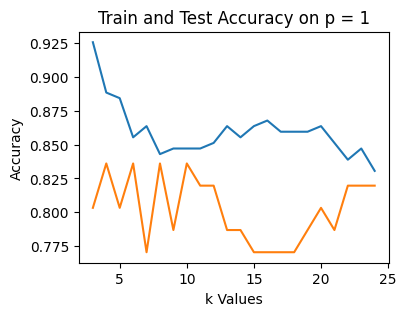

In [214]:
train_accuracy_list = []
test_accuracy_list = []
for k in np.arange(3,25):
    
    knn_clf_model = KNeighborsClassifier(n_neighbors=k, p = 1)
    knn_clf_model.fit(x_train, y_train)

    train_accuracy = knn_clf_model.score(x_train, y_train)
    train_accuracy_list.append(train_accuracy)

    test_accuracy = knn_clf_model.score(x_test, y_test)
    test_accuracy_list.append(test_accuracy)
    
plt.figure(figsize=(4,3))
k = np.arange(3,25)
plt.plot(k,train_accuracy_list)
plt.plot(k,test_accuracy_list)
plt.title('Train and Test Accuracy on p = 1')
plt.xlabel('k Values')
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

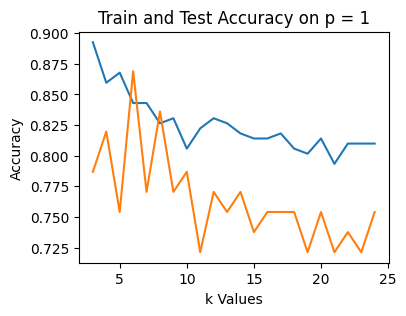

In [215]:
train_accuracy_list = []
test_accuracy_list = []
for k in np.arange(3,25):
    
    knn_clf_model = KNeighborsClassifier(n_neighbors=k, p = 2)
    knn_clf_model.fit(x_train, y_train)

    train_accuracy = knn_clf_model.score(x_train, y_train)
    train_accuracy_list.append(train_accuracy)

    test_accuracy = knn_clf_model.score(x_test, y_test)
    test_accuracy_list.append(test_accuracy)
    
plt.figure(figsize=(4,3))
k = np.arange(3,25)
plt.plot(k,train_accuracy_list)
plt.plot(k,test_accuracy_list)
plt.title('Train and Test Accuracy on p = 1')
plt.xlabel('k Values')
plt.ylabel("Accuracy")

In [216]:
#As we can see k = 6 is the best value which will give us best accuracy values for testing data with low bias and low variance  type: ignore

## Standardization

In [217]:
std_scalar = StandardScaler()
array2 = std_scalar.fit_transform(new_x)
std_df = pd.DataFrame(array2, columns = new_x.columns)

In [218]:
x_train, x_test, y_train,y_test = train_test_split(std_df, new_y, test_size= 0.2, random_state= 42, stratify= new_y)

In [219]:
knn_clf_std = KNeighborsClassifier()
knn_clf_std.fit(x_train, y_train)

KNeighborsClassifier()

### Evalution of Training data

In [220]:
y_pred_train_knn_std = knn_clf_std.predict(x_train)
Train_Models_list.append('KNN_clf_StdScaling_train')

knn_cnf_matrix_train_std = confusion_matrix(y_train, y_pred_train_knn_std)
print("Confusion_matrix :\n", knn_cnf_matrix_train_std)
print("*"*50)

knn_precision_score_train_std = precision_score(y_train, y_pred_train_knn_std)
print("Precision score :", knn_precision_score_train_std)
Train_precision_score_list.append(np.around(knn_precision_score_train_std, 3))
print("*"*50)

knn_acc_score_train_std = accuracy_score(y_train, y_pred_train_knn_std)
print("Accuracy_score :", knn_acc_score_train_std)
Train_accuracy_score_list.append(np.around(knn_acc_score_train_std, 3))
print("*"*50)

knn_f1_score_train_std = f1_score(y_train, y_pred_train_knn_std)
print("F1_score :", knn_f1_score_train_std)
Train_f1_score_list.append(np.around(knn_f1_score_train_std, 3))
print("*"*50)

knn_recall_score_train_std = recall_score(y_train, y_pred_train_knn_std)
print("Recall_score :", knn_recall_score_train_std)
Train_recall_score_list.append(np.around(knn_recall_score_train_std, 3))
print("*"*50)

knn_clf_report_train_std = classification_report(y_train, y_pred_train_knn_std)
print("Confusion_matrix :\n", knn_clf_report_train_std)
print("*"*50)

Confusion_matrix :
 [[ 92  18]
 [ 14 118]]
**************************************************
Precision score : 0.8676470588235294
**************************************************
Accuracy_score : 0.8677685950413223
**************************************************
F1_score : 0.8805970149253731
**************************************************
Recall_score : 0.8939393939393939
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.87      0.84      0.85       110
           1       0.87      0.89      0.88       132

    accuracy                           0.87       242
   macro avg       0.87      0.87      0.87       242
weighted avg       0.87      0.87      0.87       242

**************************************************


#### Evalution on Testing Data

In [221]:
y_pred_test_knn_std = knn_clf_std.predict(x_test)
Test_Models_list.append('KNN_clf_StdScalar_test')

knn_cnf_matrix_test_std = confusion_matrix(y_test, y_pred_test_knn_std)
print("Confusion_matrix :\n", knn_cnf_matrix_test_std)
print("*"*50)

knn_precision_score_test_std = precision_score(y_test, y_pred_test_knn_std)
print("Precision score :", knn_precision_score_test_std)
Test_precision_score_list.append(np.around(knn_precision_score_test_std, 3))
print("*"*50)

knn_acc_score_test_std = accuracy_score(y_test, y_pred_test_knn_std)
print("Accuracy_score :", knn_acc_score_test_std)
Test_accuracy_score_list.append(np.around(knn_acc_score_test_std, 3))
print("*"*50)

knn_f1_score_test_std = f1_score(y_test, y_pred_test_knn_std)
print("F1_score :", knn_f1_score_test_std)
Test_f1_score_list.append(np.around(knn_f1_score_test_std, 3))
print("*"*50)

knn_recall_score_test_std = recall_score(y_test, y_pred_test_knn_std)
print("Recall_score :", knn_recall_score_test_std)
Test_recall_score_list.append(np.around(knn_recall_score_test_std, 3))
print("*"*50)

knn_clf_report_test_std = classification_report(y_test, y_pred_test_knn_std)
print("Confusion_matrix :\n", knn_clf_report_test_std)
print("*"*50)

Confusion_matrix :
 [[19  9]
 [ 3 30]]
**************************************************
Precision score : 0.7692307692307693
**************************************************
Accuracy_score : 0.8032786885245902
**************************************************
F1_score : 0.8333333333333334
**************************************************
Recall_score : 0.9090909090909091
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

**************************************************


### Hyperparameter tuning on KNN clf (Standardization)

In [222]:
knn_model_std = KNeighborsClassifier()

hyperparameters = {
    'n_neighbors' : np.arange(3,20),
    'p' : [1,2]
        }

gscv_knn_model = GridSearchCV(knn_model_std, hyperparameters, cv = 5) # cv >> 3 to 10
gscv_knn_model.fit(x_train, y_train)
knn_hyp_model_std = gscv_knn_model.best_estimator_
knn_hyp_model_std.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=np.int64(9), p=1)

#### Evaluation on traning data

In [223]:
y_pred_train_knn_std_hyp = knn_hyp_model_std.predict(x_train)
Train_Models_list.append('KNN_clf_Hyp_Std_train')

knn_cnf_matrix_train_hyp_std = confusion_matrix(y_train, y_pred_train_knn_std_hyp)
print("Confusion_matrix :\n", knn_cnf_matrix_train_hyp_std)
print("*"*50)

knn_precision_score_train_hyp_std = precision_score(y_train, y_pred_train_knn_std_hyp)
print("Precision score :", knn_precision_score_train_hyp_std)
Train_precision_score_list.append(np.around(knn_precision_score_train_hyp_std, 3))
print("*"*50)

knn_acc_score_train_hyp_std = accuracy_score(y_train, y_pred_train_knn_std_hyp)
print("Accuracy_score :", knn_acc_score_train_hyp_std)
Train_accuracy_score_list.append(np.around(knn_acc_score_train_hyp_std, 3))
print("*"*50)

knn_f1_score_train_hyp_std = f1_score(y_train, y_pred_train_knn_std_hyp)
print("F1_score :", knn_f1_score_train_hyp_std)
Train_f1_score_list.append(np.around(knn_f1_score_train_hyp_std, 3))
print("*"*50)

knn_recall_score_train_hyp_std = recall_score(y_train, y_pred_train_knn_std_hyp)
print("Recall_score :", knn_recall_score_train_hyp_std)
Train_recall_score_list.append(np.around(knn_recall_score_train_hyp_std, 3))
print("*"*50)

knn_clf_report_train_hyp_std = classification_report(y_train, y_pred_train_knn_std_hyp)
print("Confusion_matrix :\n", knn_clf_report_train_hyp_std)
print("*"*50)

Confusion_matrix :
 [[ 87  23]
 [ 12 120]]
**************************************************
Precision score : 0.8391608391608392
**************************************************
Accuracy_score : 0.8553719008264463
**************************************************
F1_score : 0.8727272727272727
**************************************************
Recall_score : 0.9090909090909091
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.88      0.79      0.83       110
           1       0.84      0.91      0.87       132

    accuracy                           0.86       242
   macro avg       0.86      0.85      0.85       242
weighted avg       0.86      0.86      0.85       242

**************************************************


#### Evalution on Testing data

In [224]:
y_pred_test_knn_hyp_std = knn_hyp_model_std.predict(x_test)
Test_Models_list.append('KNN_clf_Hyp_StdSclr_test')

knn_cnf_matrix_test_hyp_std = confusion_matrix(y_test, y_pred_test_knn_hyp_std)
print("Confusion_matrix :\n", knn_cnf_matrix_test_hyp_std)
print("*"*50)

knn_precision_score_test_hyp_std = precision_score(y_test, y_pred_test_knn_hyp_std)
print("Precision score :", knn_precision_score_test_hyp_std)
Test_precision_score_list.append(np.around(knn_precision_score_test_hyp_std, 3))
print("*"*50)

knn_acc_score_test_hyp_std = accuracy_score(y_test, y_pred_test_knn_hyp_std)
print("Accuracy_score :", knn_acc_score_test_hyp_std)
Test_accuracy_score_list.append(np.around(knn_acc_score_test_hyp_std, 3))
print("*"*50)

knn_f1_score_test_hyp_std = f1_score(y_test, y_pred_test_knn_hyp_std)
print("F1_score :", knn_f1_score_test_hyp_std)
Test_f1_score_list.append(np.around(knn_f1_score_test_hyp_std, 3))
print("*"*50)

knn_recall_score_test_hyp_std = recall_score(y_test, y_pred_test_knn_hyp_std)
print("Recall_score :", knn_recall_score_test_hyp_std)
Test_recall_score_list.append(np.around(knn_recall_score_test_hyp_std, 3))
print("*"*50)

knn_clf_report_test_hyp_std = classification_report(y_test, y_pred_test_knn_hyp_std)
print("Confusion_matrix :\n", knn_clf_report_test_hyp_std)
print("*"*50)

Confusion_matrix :
 [[21  7]
 [ 2 31]]
**************************************************
Precision score : 0.8157894736842105
**************************************************
Accuracy_score : 0.8524590163934426
**************************************************
F1_score : 0.8732394366197183
**************************************************
Recall_score : 0.9393939393939394
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.91      0.75      0.82        28
           1       0.82      0.94      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.86      0.85      0.85        61

**************************************************


#### Traning on different k values

Text(0, 0.5, 'Accuracy')

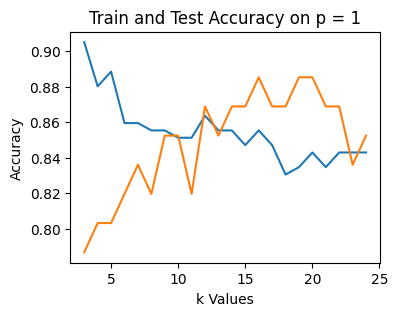

In [225]:
train_accuracy_list = []
test_accuracy_list = []
for k in np.arange(3,25):
    
    knn_clf_model = KNeighborsClassifier(n_neighbors=k, p = 1)
    knn_clf_model.fit(x_train, y_train)

    train_accuracy = knn_clf_model.score(x_train, y_train)
    train_accuracy_list.append(train_accuracy)

    test_accuracy = knn_clf_model.score(x_test, y_test)
    test_accuracy_list.append(test_accuracy)
    
plt.figure(figsize=(4,3))
k = np.arange(3,25)
plt.plot(k,train_accuracy_list)
plt.plot(k,test_accuracy_list)
plt.title('Train and Test Accuracy on p = 1')
plt.xlabel('k Values')
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

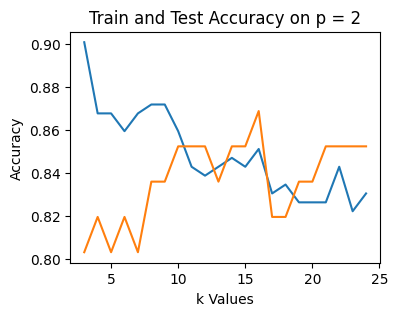

In [226]:
train_accuracy_list = []
test_accuracy_list = []
for k in np.arange(3,25):
    
    knn_clf_model = KNeighborsClassifier(n_neighbors=k, p = 2)
    knn_clf_model.fit(x_train, y_train)

    train_accuracy = knn_clf_model.score(x_train, y_train)
    train_accuracy_list.append(train_accuracy)

    test_accuracy = knn_clf_model.score(x_test, y_test)
    test_accuracy_list.append(test_accuracy)
    
plt.figure(figsize=(4,3))
k = np.arange(3,25)
plt.plot(k,train_accuracy_list)
plt.plot(k,test_accuracy_list)
plt.title('Train and Test Accuracy on p = 2')
plt.xlabel('k Values')
plt.ylabel("Accuracy")

# 3)  Decision Tree clf

In [227]:
new_x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
19,69,0,3,140,239.0,0,1,151,0,1.8,2,2,2
247,66,1,1,160,246.0,0,1,120,1,0.0,1,3,1
289,55,0,0,128,205.0,0,2,130,1,2.0,1,1,3
288,57,1,0,110,335.0,0,1,143,1,3.0,1,1,3
60,71,0,2,110,265.0,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,58,0,3,150,283.0,1,0,162,0,1.0,2,0,2
4,57,0,0,120,354.0,0,1,163,1,0.6,2,0,2
224,54,1,0,110,239.0,0,1,126,1,2.8,1,1,3
202,58,1,0,150,270.0,0,0,111,1,0.8,2,0,3


In [228]:
x_train, x_test, y_train, y_test = train_test_split(new_x, new_y, test_size= 0.2, random_state= 42, stratify= new_y)

In [229]:
dt_clf = DecisionTreeClassifier(random_state= 18)
dt_clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=18)

#### Evalution on Traning data

In [230]:
y_pred_train_DT = dt_clf.predict(x_train)
Train_Models_list.append('DT_clf_train')

DT_cnf_matrix_train = confusion_matrix(y_train, y_pred_train_DT)
print("Confusion_matrix :\n", DT_cnf_matrix_train)
print("*"*50)

DT_precision_score_train = precision_score(y_train, y_pred_train_DT)
print("Precision score :", DT_precision_score_train)
Train_precision_score_list.append(np.around(DT_precision_score_train, 3))
print("*"*50)

DT_acc_score_train = accuracy_score(y_train, y_pred_train_DT)
print("Accuracy_score :", DT_acc_score_train)
Train_accuracy_score_list.append(np.around(DT_acc_score_train, 3))
print("*"*50)

DT_f1_score_train = f1_score(y_train, y_pred_train_DT)
print("F1_score :", DT_f1_score_train)
Train_f1_score_list.append(np.around(DT_f1_score_train, 3))
print("*"*50)

DT_recall_score_train = recall_score(y_train, y_pred_train_DT)
print("Recall_score :", DT_recall_score_train)
Train_recall_score_list.append(np.around(DT_recall_score_train, 3))
print("*"*50)

DT_clf_report_train = classification_report(y_train, y_pred_train_DT)
print("Confusion_matrix :\n", DT_clf_report_train)
print("*"*50)

Confusion_matrix :
 [[110   0]
 [  0 132]]
**************************************************
Precision score : 1.0
**************************************************
Accuracy_score : 1.0
**************************************************
F1_score : 1.0
**************************************************
Recall_score : 1.0
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       132

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

**************************************************


#### Evalution on Testing data

In [231]:
y_pred_test_DT = dt_clf.predict(x_test)
Test_Models_list.append('DT_clf_test')

DT_matrix_test = confusion_matrix(y_test, y_pred_test_DT)
print("Confusion_matrix :\n", DT_matrix_test)
print("*"*50)

DT_precision_score_test = precision_score(y_test, y_pred_test_DT)
print("Precision score :", DT_precision_score_test)
Test_precision_score_list.append(np.around(DT_precision_score_test, 3))
print("*"*50)

DT_acc_score_test = accuracy_score(y_test, y_pred_test_DT)
print("Accuracy_score :", DT_acc_score_test)
Test_accuracy_score_list.append(np.around(DT_acc_score_test, 3))
print("*"*50)

DT_f1_score_test = f1_score(y_test, y_pred_test_DT)
print("F1_score :", DT_f1_score_test)
Test_f1_score_list.append(np.around(DT_f1_score_test, 3))
print("*"*50)

DT_recall_score_test = recall_score(y_test, y_pred_test_DT)
print("Recall_score :", DT_recall_score_test)
Test_recall_score_list.append(np.around(DT_recall_score_test, 3))
print("*"*50)

DT_clf_report_test = classification_report(y_test,y_pred_test_DT)
print("Confusion_matrix :\n", DT_clf_report_test)
print("*"*50)

Confusion_matrix :
 [[22  6]
 [ 5 28]]
**************************************************
Precision score : 0.8235294117647058
**************************************************
Accuracy_score : 0.819672131147541
**************************************************
F1_score : 0.835820895522388
**************************************************
Recall_score : 0.8484848484848485
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

**************************************************


<Axes: >

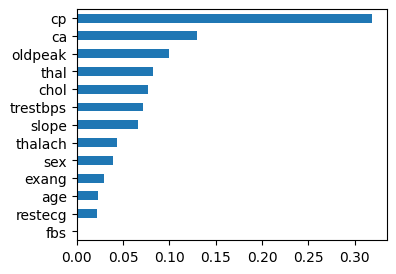

In [232]:
plt.figure(figsize=(4, 3))
s1 = pd.Series(dt_clf.feature_importances_, index=new_x.columns)
s1.sort_values().plot(kind = 'barh')

## HyperParameter Tuning DT

In [233]:
dt_model = DecisionTreeClassifier(random_state= 18)

Hyperparameters = {"criterion" : ['entropy', 'gini'],
                  "max_depth" : np.arange(4,10),
                  "min_samples_split":np.arange(5,20),
                  "min_samples_leaf":np.arange(3,10)
                  }

gscv_DT_model = GridSearchCV(dt_model,Hyperparameters, cv = 5, n_jobs= -1)
gscv_DT_model.fit(x_train, y_train)
dt_hyp_model = gscv_DT_model.best_estimator_
dt_hyp_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(6),
                       min_samples_leaf=np.int64(6),
                       min_samples_split=np.int64(5), random_state=18)

### Evalution of Traning data

In [234]:
y_pred_train_DT_hyp = dt_hyp_model.predict(x_train)
Train_Models_list.append('DT_clf_Hyp_train')

DT_cnf_matrix_train_hyp = confusion_matrix(y_train, y_pred_train_DT_hyp)
print("Confusion_matrix :\n", DT_cnf_matrix_train_hyp)
print("*"*50)

DT_precision_score_train_hyp = precision_score(y_train, y_pred_train_DT_hyp)
print("Precision score :", DT_precision_score_train_hyp)
Train_precision_score_list.append(np.around(DT_precision_score_train_hyp, 3))
print("*"*50)

DT_acc_score_train_hyp = accuracy_score(y_train, y_pred_train_DT_hyp)
print("Accuracy_score :", DT_acc_score_train_hyp)
Train_accuracy_score_list.append(np.around(DT_acc_score_train_hyp, 3))
print("*"*50)

DT_f1_score_train_hyp = f1_score(y_train, y_pred_train_DT_hyp)
print("F1_score :", DT_f1_score_train_hyp)
Train_f1_score_list.append(np.around(DT_f1_score_train_hyp, 3))
print("*"*50)

DT_recall_score_train_hyp = recall_score(y_train, y_pred_train_DT_hyp)
print("Recall_score :", DT_recall_score_train_hyp)
Train_recall_score_list.append(np.around(DT_recall_score_train_hyp, 3))
print("*"*50)

DT_clf_report_train_hyp = classification_report(y_train, y_pred_train_DT_hyp)
print("Confusion_matrix :\n", DT_clf_report_train_hyp)
print("*"*50)

Confusion_matrix :
 [[100  10]
 [ 14 118]]
**************************************************
Precision score : 0.921875
**************************************************
Accuracy_score : 0.9008264462809917
**************************************************
F1_score : 0.9076923076923077
**************************************************
Recall_score : 0.8939393939393939
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       110
           1       0.92      0.89      0.91       132

    accuracy                           0.90       242
   macro avg       0.90      0.90      0.90       242
weighted avg       0.90      0.90      0.90       242

**************************************************


#### Evalution on Testing data

In [235]:
y_pred_test_DT_hyp = dt_hyp_model.predict(x_test)
Test_Models_list.append('DT_clf_Hyp_test')

DT_matrix_test_hyp = confusion_matrix(y_test, y_pred_test_DT_hyp)
print("Confusion_matrix :\n", DT_matrix_test_hyp)
print("*"*50)

DT_precision_score_test_hyp = precision_score(y_test, y_pred_test_DT_hyp)
print("Precision score :", DT_precision_score_test_hyp)
Test_precision_score_list.append(np.around(DT_precision_score_test_hyp, 3))
print("*"*50)

DT_acc_score_test_hyp = accuracy_score(y_test, y_pred_test_DT_hyp)
print("Accuracy_score :", DT_acc_score_test_hyp)
Test_accuracy_score_list.append(np.around(DT_acc_score_test_hyp, 3))
print("*"*50)

DT_f1_score_test_hyp = f1_score(y_test, y_pred_test_DT_hyp)
print("F1_score :", DT_f1_score_test_hyp)
Test_f1_score_list.append(np.around(DT_f1_score_test_hyp, 3))
print("*"*50)

DT_recall_score_test_hyp = recall_score(y_test, y_pred_test_DT_hyp)
print("Recall_score :", DT_recall_score_test_hyp)
Test_recall_score_list.append(np.around(DT_recall_score_test_hyp, 3))
print("*"*50)

DT_clf_report_test_hyp = classification_report(y_test,y_pred_test_DT_hyp)
print("Confusion_matrix :\n", DT_clf_report_test_hyp)
print("*"*50)

Confusion_matrix :
 [[22  6]
 [ 7 26]]
**************************************************
Precision score : 0.8125
**************************************************
Accuracy_score : 0.7868852459016393
**************************************************
F1_score : 0.8
**************************************************
Recall_score : 0.7878787878787878
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

**************************************************


<Axes: >

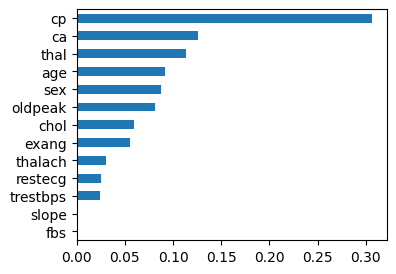

In [236]:
plt.figure(figsize=(4, 3))
s1 = pd.Series(dt_hyp_model.feature_importances_, index=new_x.columns)
s1.sort_values().plot(kind = 'barh')

### Pruning

In [237]:
dt_clf_pruning = DecisionTreeClassifier(random_state=18)
dt_clf_pruning.fit(x_train, y_train)

DecisionTreeClassifier(random_state=18)

In [238]:
result = dt_clf_pruning.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = result['ccp_alphas']
ccp_alphas

array([0.        , 0.00255805, 0.00371901, 0.00385675, 0.00390266,
       0.00405426, 0.00495868, 0.005244  , 0.00550964, 0.00550964,
       0.00573003, 0.00590319, 0.00619835, 0.00619835, 0.00629673,
       0.00688705, 0.006903  , 0.00768056, 0.00770122, 0.00981396,
       0.01145748, 0.01178474, 0.01941066, 0.02020208, 0.04080415,
       0.04268399, 0.14145968])

In [239]:
train_acc_list = []
test_acc_list = []
for ccp_alpha in ccp_alphas:
    dt_clf_pruning = DecisionTreeClassifier(random_state=18, ccp_alpha=ccp_alpha)
    dt_clf_pruning.fit(x_train, y_train)
    
    train_acc = dt_clf_pruning.score(x_train, y_train)
    train_acc_list.append(train_acc)
    
    test_acc = dt_clf_pruning.score(x_test, y_test)
    test_acc_list.append(test_acc)
#     print(ccp_alpha, test_acc,train_acc )

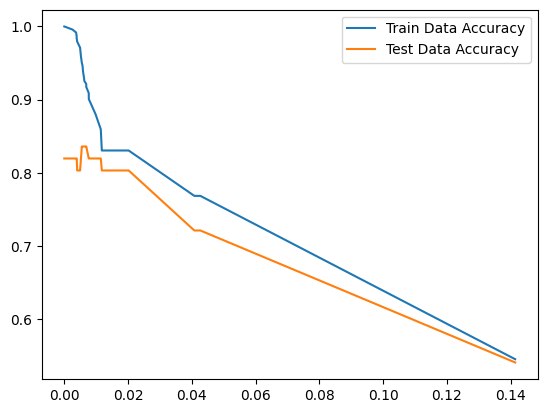

In [240]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas,train_acc_list, label = 'Train Data Accuracy' )
ax.plot(ccp_alphas, test_acc_list, label = 'Test Data Accuracy')
ax.legend()

In [241]:
train_acc_list = []
test_acc_list = []
for ccp_alpha in ccp_alphas:
    if (ccp_alpha > 0.01) and (ccp_alpha < 0.02) :
        dt_clf_pruning = DecisionTreeClassifier(random_state=18, ccp_alpha=ccp_alpha)
        dt_clf_pruning.fit(x_train, y_train)

        train_acc = dt_clf_pruning.score(x_train, y_train)
        train_acc_list.append(train_acc)

        test_acc = dt_clf_pruning.score(x_test, y_test)
        test_acc_list.append(test_acc)
        print(ccp_alpha, test_acc,train_acc)

0.011457481912027364 0.819672131147541 0.859504132231405
0.011784741496493167 0.8032786885245902 0.8305785123966942
0.019410662426183473 0.8032786885245902 0.8305785123966942


In [242]:
#You are getting best accuracy score on above "C" values 

# 4) >>>>>>>>>>>>>>>>>> Random Forest Clf <<<<<<<<<<<<<<<<<<<<<<<<

In [243]:
rf_clf = RandomForestClassifier()
rf_clf.fit(x_train, y_train)

RandomForestClassifier()

#### Evalution on Traning data

In [244]:
y_pred_train_RF = rf_clf.predict(x_train)
Train_Models_list.append('RF_clf_train')

RF_cnf_matrix_train = confusion_matrix(y_train, y_pred_train_RF)
print("Confusion_matrix :\n", RF_cnf_matrix_train)
print("*"*50)

RF_precision_score_train = precision_score(y_train, y_pred_train_RF)
print("Precision score :", RF_precision_score_train)
Train_precision_score_list.append(np.around(RF_precision_score_train, 3))
print("*"*50)

RF_acc_score_train = accuracy_score(y_train, y_pred_train_RF)
print("Accuracy_score :", RF_acc_score_train)
Train_accuracy_score_list.append(np.around(RF_acc_score_train, 3))
print("*"*50)

RF_f1_score_train = f1_score(y_train, y_pred_train_RF)
print("F1_score :", RF_f1_score_train)
Train_f1_score_list.append(np.around(RF_f1_score_train, 3))
print("*"*50)

RF_recall_score_train = recall_score(y_train, y_pred_train_RF)
print("Recall_score :", RF_recall_score_train)
Train_recall_score_list.append(np.around(RF_recall_score_train, 3))
print("*"*50)

RF_clf_report_train = classification_report(y_train, y_pred_train_RF)
print("Confusion_matrix :\n", RF_clf_report_train)
print("*"*50)

Confusion_matrix :
 [[110   0]
 [  0 132]]
**************************************************
Precision score : 1.0
**************************************************
Accuracy_score : 1.0
**************************************************
F1_score : 1.0
**************************************************
Recall_score : 1.0
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       132

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

**************************************************


#### Evalution on Testing data

In [245]:
y_pred_test_RF = dt_clf.predict(x_test)
Test_Models_list.append('RF_clf_test')

RF_matrix_test = confusion_matrix(y_test, y_pred_test_RF)
print("Confusion_matrix :\n", RF_matrix_test)
print("*"*50)

RF_precision_score_test = precision_score(y_test, y_pred_test_RF)
print("Precision score :", RF_precision_score_test)
Test_precision_score_list.append(np.around(RF_precision_score_test, 3))
print("*"*50)

RF_acc_score_test = accuracy_score(y_test, y_pred_test_RF)
print("Accuracy_score :", RF_acc_score_test)
Test_accuracy_score_list.append(np.around(RF_acc_score_test, 3))
print("*"*50)

RF_f1_score_test = f1_score(y_test, y_pred_test_RF)
print("F1_score :", RF_f1_score_test)
Test_f1_score_list.append(np.around(RF_f1_score_test, 3))
print("*"*50)

RF_recall_score_test = recall_score(y_test, y_pred_test_RF)
print("Recall_score :", RF_recall_score_test)
Test_recall_score_list.append(np.around(RF_recall_score_test, 3))
print("*"*50)

RF_clf_report_test = classification_report(y_test,y_pred_test_RF)
print("Confusion_matrix :\n", RF_clf_report_test)
print("*"*50)

Confusion_matrix :
 [[22  6]
 [ 5 28]]
**************************************************
Precision score : 0.8235294117647058
**************************************************
Accuracy_score : 0.819672131147541
**************************************************
F1_score : 0.835820895522388
**************************************************
Recall_score : 0.8484848484848485
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

**************************************************


<Axes: >

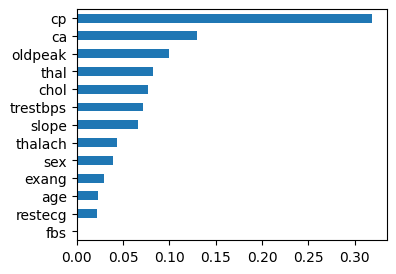

In [246]:
plt.figure(figsize=(4, 3))
s1 = pd.Series(dt_clf.feature_importances_, index= x.columns)
s1.sort_values().plot(kind = 'barh')

## Hyperparameter Tuning on (Random Forest)

In [247]:
x_train.shape

(242, 13)

In [248]:
rf_model = RandomForestClassifier(random_state= 18, n_jobs= -1, max_features= "sqrt", bootstrap= True, oob_score=True)

hyper_para = {'n_estimators' : np.arange(10,100),
    'criterion' : ['entropy','gini'],
    'max_depth' : np.arange(2,8),
    'min_samples_split' : np.arange(3,15),
    'min_samples_leaf' : np.arange(2,10)
    }

gscv_rf_model = RandomizedSearchCV(rf_model, hyper_para, cv = 5, n_jobs= -1)
gscv_rf_model.fit(x_train, y_train)
rf_hyp_model = gscv_rf_model.best_estimator_
rf_hyp_model.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=np.int64(4),
                       min_samples_leaf=np.int64(5),
                       min_samples_split=np.int64(7), n_estimators=np.int64(82),
                       n_jobs=-1, oob_score=True, random_state=18)

#### Evalution on Traning data

In [249]:
y_pred_train_RF_hyp = rf_hyp_model.predict(x_train)
Train_Models_list.append('RF_clf_Hyp_train')

RF_cnf_matrix_train_hyp = confusion_matrix(y_train, y_pred_train_RF_hyp)
print("Confusion_matrix :\n", RF_cnf_matrix_train_hyp)
print("*"*50)

RF_precision_score_train_hyp = precision_score(y_train, y_pred_train_RF_hyp)
print("Precision score :", RF_precision_score_train_hyp)
Train_precision_score_list.append(np.around(RF_precision_score_train_hyp, 3))
print("*"*50)

RF_acc_score_train_hyp = accuracy_score(y_train, y_pred_train_RF_hyp)
print("Accuracy_score :", RF_acc_score_train_hyp)
Train_accuracy_score_list.append(np.around(RF_acc_score_train_hyp, 3))
print("*"*50)

RF_f1_score_train_hyp = f1_score(y_train, y_pred_train_RF_hyp)
print("F1_score :", RF_f1_score_train_hyp)
Train_f1_score_list.append(np.around(RF_f1_score_train_hyp, 3))
print("*"*50)

RF_recall_score_train_hyp = recall_score(y_train, y_pred_train_RF_hyp)
print("Recall_score :", RF_recall_score_train_hyp)
Train_recall_score_list.append(np.around(RF_recall_score_train_hyp, 3))
print("*"*50)

RF_clf_report_train_hyp = classification_report(y_train, y_pred_train_RF_hyp)
print("Confusion_matrix :\n", RF_clf_report_train_hyp)
print("*"*50)

Confusion_matrix :
 [[ 92  18]
 [  7 125]]
**************************************************
Precision score : 0.8741258741258742
**************************************************
Accuracy_score : 0.8966942148760331
**************************************************
F1_score : 0.9090909090909091
**************************************************
Recall_score : 0.946969696969697
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.93      0.84      0.88       110
           1       0.87      0.95      0.91       132

    accuracy                           0.90       242
   macro avg       0.90      0.89      0.89       242
weighted avg       0.90      0.90      0.90       242

**************************************************


#### Evalution on Testing data

In [250]:
y_pred_test_RF_hyp = rf_hyp_model.predict(x_test)
Test_Models_list.append('RF_clf_Hyp_test')

RF_matrix_test_hyp = confusion_matrix(y_test, y_pred_test_RF_hyp)
print("Confusion_matrix :\n", RF_matrix_test_hyp)
print("*"*50)

RF_precision_score_test_hyp = precision_score(y_test, y_pred_test_RF_hyp)
print("Precision score :", RF_precision_score_test_hyp)
Test_precision_score_list.append(np.around(RF_precision_score_test_hyp, 3))
print("*"*50)

RF_acc_score_test_hyp = accuracy_score(y_test, y_pred_test_RF_hyp)
print("Accuracy_score :", RF_acc_score_test_hyp)
Test_accuracy_score_list.append(np.around(RF_acc_score_test_hyp, 3))
print("*"*50)

RF_f1_score_test_hyp = f1_score(y_test, y_pred_test_RF_hyp)
print("F1_score :", RF_f1_score_test_hyp)
Test_f1_score_list.append(np.around(RF_f1_score_test_hyp, 3))
print("*"*50)

RF_recall_score_test_hyp = recall_score(y_test, y_pred_test_RF_hyp)
print("Recall_score :", RF_recall_score_test_hyp)
Test_recall_score_list.append(np.around(RF_recall_score_test_hyp, 3))
print("*"*50)

RF_clf_report_test_hyp = classification_report(y_test,y_pred_test_RF_hyp)
print("Confusion_matrix :\n", RF_clf_report_test_hyp)
print("*"*50)

Confusion_matrix :
 [[21  7]
 [ 4 29]]
**************************************************
Precision score : 0.8055555555555556
**************************************************
Accuracy_score : 0.819672131147541
**************************************************
F1_score : 0.8405797101449275
**************************************************
Recall_score : 0.8787878787878788
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.84      0.75      0.79        28
           1       0.81      0.88      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.82        61
weighted avg       0.82      0.82      0.82        61

**************************************************


<Axes: >

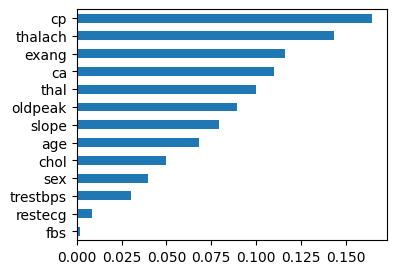

In [251]:
plt.figure(figsize=(4, 3))
s1 = pd.Series(rf_hyp_model.feature_importances_, index= x.columns)
s1.sort_values().plot(kind = 'barh')

# 5) >>>>>>>>>>>>>>>>>> Adaptive Boosting Clf <<<<<<<<<<<<<<<<<<<<<

In [252]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(new_x, new_y, test_size= 0.2, random_state= 42, stratify= new_y)

In [253]:
model_dt_clf = DecisionTreeClassifier(random_state= 18)

Ada_boost_clf = AdaBoostClassifier(random_state=18)
Ada_boost_clf.fit(x_train, y_train)

AdaBoostClassifier(random_state=18)

#### Evalution on Traning data

In [254]:
y_pred_train_ada_boost = Ada_boost_clf.predict(x_train)
Train_Models_list.append('Ada_boost_clf_train')

Ada_boost_cnf_matrix_train = confusion_matrix(y_train, y_pred_train_ada_boost)
print("Confusion_matrix :\n", Ada_boost_cnf_matrix_train)
print("*"*50)

Ada_boost_precision_score_train = precision_score(y_train, y_pred_train_ada_boost)
print("Precision score :", Ada_boost_precision_score_train)
Train_precision_score_list.append(np.around(Ada_boost_precision_score_train, 3))
print("*"*50)

Ada_boost_acc_score_train = accuracy_score(y_train, y_pred_train_ada_boost)
print("Accuracy_score :", Ada_boost_acc_score_train)
Train_accuracy_score_list.append(np.around(Ada_boost_acc_score_train, 3))
print("*"*50)

Ada_boost_f1_score_train = f1_score(y_train, y_pred_train_ada_boost)
print("F1_score :", Ada_boost_f1_score_train)
Train_f1_score_list.append(np.around(Ada_boost_f1_score_train, 3))
print("*"*50)

Ada_boost_recall_score_train = recall_score(y_train, y_pred_train_ada_boost)
print("Recall_score :", Ada_boost_recall_score_train)
Train_recall_score_list.append(np.around(Ada_boost_recall_score_train, 3))
print("*"*50)

Ada_boost_clf_report_train = classification_report(y_train, y_pred_train_ada_boost)
print("Confusion_matrix :\n", Ada_boost_clf_report_train)
print("*"*50)

Confusion_matrix :
 [[ 93  17]
 [ 11 121]]
**************************************************
Precision score : 0.8768115942028986
**************************************************
Accuracy_score : 0.8842975206611571
**************************************************
F1_score : 0.8962962962962963
**************************************************
Recall_score : 0.9166666666666666
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       110
           1       0.88      0.92      0.90       132

    accuracy                           0.88       242
   macro avg       0.89      0.88      0.88       242
weighted avg       0.88      0.88      0.88       242

**************************************************


#### Evalution on Testing data

In [255]:
y_pred_test_ada_boost = Ada_boost_clf.predict(x_test)
Test_Models_list.append('Ada_boost_clf_test')

Ada_boost_matrix_test = confusion_matrix(y_test, y_pred_test_ada_boost)
print("Confusion_matrix :\n", Ada_boost_matrix_test)
print("*"*50)

Ada_boost_precision_score_test = precision_score(y_test, y_pred_test_ada_boost)
print("Precision score :", Ada_boost_precision_score_test)
Test_precision_score_list.append(np.around(Ada_boost_precision_score_test, 3))
print("*"*50)

Ada_boost_acc_score_test = accuracy_score(y_test, y_pred_test_ada_boost)
print("Accuracy_score :", Ada_boost_acc_score_test)
Test_accuracy_score_list.append(np.around(Ada_boost_acc_score_test, 3))
print("*"*50)

Ada_boost_f1_score_test = f1_score(y_test, y_pred_test_ada_boost)
print("F1_score :", Ada_boost_f1_score_test)
Test_f1_score_list.append(np.around(Ada_boost_f1_score_test, 3))
print("*"*50)

Ada_boost_recall_score_test = recall_score(y_test, y_pred_test_ada_boost)
print("Recall_score :", Ada_boost_recall_score_test)
Test_recall_score_list.append(np.around(Ada_boost_recall_score_test, 3))
print("*"*50)

Ada_boost_clf_report_test = classification_report(y_test,y_pred_test_ada_boost)
print("Confusion_matrix :\n", Ada_boost_clf_report_test)
print("*"*50)

Confusion_matrix :
 [[23  5]
 [ 3 30]]
**************************************************
Precision score : 0.8571428571428571
**************************************************
Accuracy_score : 0.8688524590163934
**************************************************
F1_score : 0.8823529411764706
**************************************************
Recall_score : 0.9090909090909091
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.88      0.82      0.85        28
           1       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

**************************************************


## Hyperparameter Tuning (Ada Boost)

In [256]:
model_dt_clf = DecisionTreeClassifier()
adaboost_clf = AdaBoostClassifier(random_state= 18)

hyp_grid = {"n_estimators" : np.arange(10,50),
            "learning_rate" : np.arange(0.01,2,0.01)}

rscv_adb_clf = RandomizedSearchCV(adaboost_clf,hyp_grid, cv = 5, random_state=10)
rscv_adb_clf.fit(x_train, y_train)
rscv_adb_clf.best_estimator_

AdaBoostClassifier(learning_rate=np.float64(0.34), n_estimators=np.int64(34),
                   random_state=18)

#### Evalution on Traning data

In [257]:
y_pred_train_ada_boost_hyp = rscv_adb_clf.predict(x_train)
Train_Models_list.append('Ada_boost_clf_Hyp_train')

Ada_boost_cnf_matrix_train_hyp = confusion_matrix(y_train, y_pred_train_ada_boost_hyp)
print("Confusion_matrix :\n", Ada_boost_cnf_matrix_train_hyp)
print("*"*50)

Ada_boost_precision_score_train_hyp = precision_score(y_train, y_pred_train_ada_boost_hyp)
print("Precision score :", Ada_boost_precision_score_train_hyp)
Train_precision_score_list.append(np.around(Ada_boost_precision_score_train_hyp, 3))
print("*"*50)

Ada_boost_acc_score_train_hyp = accuracy_score(y_train, y_pred_train_ada_boost_hyp)
print("Accuracy_score :", Ada_boost_acc_score_train_hyp)
Train_accuracy_score_list.append(np.around(Ada_boost_acc_score_train_hyp, 3))
print("*"*50)

Ada_boost_f1_score_train_hyp = f1_score(y_train, y_pred_train_ada_boost_hyp)
print("F1_score :", Ada_boost_f1_score_train_hyp)
Train_f1_score_list.append(np.around(Ada_boost_f1_score_train_hyp, 3))
print("*"*50)

Ada_boost_recall_score_train_hyp = recall_score(y_train, y_pred_train_ada_boost_hyp)
print("Recall_score :", Ada_boost_recall_score_train_hyp)
Train_recall_score_list.append(np.around(Ada_boost_recall_score_train_hyp, 3))
print("*"*50)

Ada_boost_clf_report_train_hyp = classification_report(y_train, y_pred_train_ada_boost_hyp)
print("Confusion_matrix :\n", Ada_boost_clf_report_train_hyp)
print("*"*50)

Confusion_matrix :
 [[ 91  19]
 [ 14 118]]
**************************************************
Precision score : 0.8613138686131386
**************************************************
Accuracy_score : 0.8636363636363636
**************************************************
F1_score : 0.8773234200743495
**************************************************
Recall_score : 0.8939393939393939
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.87      0.83      0.85       110
           1       0.86      0.89      0.88       132

    accuracy                           0.86       242
   macro avg       0.86      0.86      0.86       242
weighted avg       0.86      0.86      0.86       242

**************************************************


#### Evalution on Testing data

In [258]:
y_pred_test_ada_boost_hyp = rscv_adb_clf.predict(x_test)
Test_Models_list.append('Ada_boost_clf_Hyp_test')

Ada_boost_matrix_test_hyp = confusion_matrix(y_test, y_pred_test_ada_boost_hyp)
print("Confusion_matrix :\n", Ada_boost_matrix_test_hyp)
print("*"*50)

Ada_boost_precision_score_test_hyp = precision_score(y_test, y_pred_test_ada_boost_hyp)
print("Precision score :", Ada_boost_precision_score_test_hyp)
Test_precision_score_list.append(np.around(Ada_boost_precision_score_test_hyp, 3))
print("*"*50)

Ada_boost_acc_score_test_hyp = accuracy_score(y_test, y_pred_test_ada_boost_hyp)
print("Accuracy_score :", Ada_boost_acc_score_test_hyp)
Test_accuracy_score_list.append(np.around(Ada_boost_acc_score_test_hyp, 3))
print("*"*50)

Ada_boost_f1_score_test_hyp = f1_score(y_test, y_pred_test_ada_boost_hyp)
print("F1_score :", Ada_boost_f1_score_test_hyp)
Test_f1_score_list.append(np.around(Ada_boost_f1_score_test_hyp, 3))
print("*"*50)

Ada_boost_recall_score_test_hyp = recall_score(y_test, y_pred_test_ada_boost_hyp)
print("Recall_score :", Ada_boost_recall_score_test_hyp)
Test_recall_score_list.append(np.around(Ada_boost_recall_score_test_hyp, 3))
print("*"*50)

Ada_boost_clf_report_test_hyp = classification_report(y_test,y_pred_test_ada_boost_hyp)
print("Confusion_matrix :\n", Ada_boost_clf_report_test_hyp)
print("*"*50)

Confusion_matrix :
 [[23  5]
 [ 4 29]]
**************************************************
Precision score : 0.8529411764705882
**************************************************
Accuracy_score : 0.8524590163934426
**************************************************
F1_score : 0.8656716417910447
**************************************************
Recall_score : 0.8787878787878788
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

**************************************************


### Change Base Model

In [259]:
base_model = DecisionTreeClassifier()

adaboost_clf = AdaBoostClassifier(estimator = base_model, learning_rate=0.5,random_state=18)
adaboost_clf.fit(x_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(), learning_rate=0.5,
                   random_state=18)

In [260]:
x_train.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [261]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 82 to 37
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       242 non-null    int64  
 1   sex       242 non-null    int64  
 2   cp        242 non-null    int64  
 3   trestbps  242 non-null    int64  
 4   chol      242 non-null    float64
 5   fbs       242 non-null    int64  
 6   restecg   242 non-null    int64  
 7   thalach   242 non-null    int64  
 8   exang     242 non-null    int64  
 9   oldpeak   242 non-null    float64
 10  slope     242 non-null    int64  
 11  ca        242 non-null    int64  
 12  thal      242 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 26.5 KB


#### Evalution on Traning data

In [262]:
y_pred_train_ada_boost_base_change = adaboost_clf.predict(x_train)
Train_Models_list.append('Adabst_clf_Base_Model_Chg_train')

Ada_boost_cnf_matrix_train_base_change = confusion_matrix(y_train, y_pred_train_ada_boost_base_change)
print("Confusion_matrix :\n", Ada_boost_cnf_matrix_train_base_change)
print("*"*50)

Ada_boost_precision_score_train_base_change = precision_score(y_train, y_pred_train_ada_boost_base_change)
print("Precision score :", Ada_boost_precision_score_train_base_change)
Train_precision_score_list.append(np.around(Ada_boost_precision_score_train_base_change, 3))
print("*"*50)

Ada_boost_acc_score_train_base_change = accuracy_score(y_train, y_pred_train_ada_boost_base_change)
print("Accuracy_score :", Ada_boost_acc_score_train_base_change)
Train_accuracy_score_list.append(np.around(Ada_boost_acc_score_train_base_change, 3))
print("*"*50)

Ada_boost_f1_score_train_base_change = f1_score(y_train, y_pred_train_ada_boost_base_change)
print("F1_score :", Ada_boost_f1_score_train_base_change)
Train_f1_score_list.append(np.around(Ada_boost_f1_score_train_base_change, 3))
print("*"*50)

Ada_boost_recall_score_train_base_change = recall_score(y_train, y_pred_train_ada_boost_base_change)
print("Recall_score :", Ada_boost_recall_score_train_base_change)
Train_recall_score_list.append(np.around(Ada_boost_recall_score_train_base_change, 3))
print("*"*50)

Ada_boost_clf_report_train_base_change = classification_report(y_train, y_pred_train_ada_boost_base_change)
print("Confusion_matrix :\n", Ada_boost_clf_report_train_base_change)
print("*"*50)

Confusion_matrix :
 [[110   0]
 [  0 132]]
**************************************************
Precision score : 1.0
**************************************************
Accuracy_score : 1.0
**************************************************
F1_score : 1.0
**************************************************
Recall_score : 1.0
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       132

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

**************************************************


#### Evalution on Testing data

In [263]:
y_pred_test_ada_boost_baseM_change = adaboost_clf.predict(x_test)
Test_Models_list.append('Adabst_clf_Base_Model_Chg_test')

Ada_boost_matrix_test_baseM_change = confusion_matrix(y_test, y_pred_test_ada_boost_baseM_change)
print("Confusion_matrix :\n", Ada_boost_matrix_test_baseM_change)
print("*"*50)

Ada_boost_precision_score_test_baseM_change = precision_score(y_test, y_pred_test_ada_boost_baseM_change)
print("Precision score :", Ada_boost_precision_score_test_baseM_change)
Test_precision_score_list.append(np.around(Ada_boost_precision_score_test_baseM_change, 3))
print("*"*50)

Ada_boost_acc_score_test_baseM_change = accuracy_score(y_test, y_pred_test_ada_boost_baseM_change)
print("Accuracy_score :", Ada_boost_acc_score_test_baseM_change)
Test_accuracy_score_list.append(np.around(Ada_boost_acc_score_test_baseM_change, 3))
print("*"*50)

Ada_boost_f1_score_test_baseM_change = f1_score(y_test, y_pred_test_ada_boost_baseM_change)
print("F1_score :", Ada_boost_f1_score_test_baseM_change)
Test_f1_score_list.append(np.around(Ada_boost_f1_score_test_baseM_change, 3))
print("*"*50)

Ada_boost_recall_score_test_baseM_change = recall_score(y_test, y_pred_test_ada_boost_baseM_change)
print("Recall_score :", Ada_boost_recall_score_test_baseM_change)
Test_recall_score_list.append(np.around(Ada_boost_recall_score_test_baseM_change, 3))
print("*"*50)

Ada_boost_clf_report_test_baseM_change = classification_report(y_test,y_pred_test_ada_boost_baseM_change)
print("Confusion_matrix :\n", Ada_boost_clf_report_test_baseM_change)
print("*"*50)

Confusion_matrix :
 [[21  7]
 [ 5 28]]
**************************************************
Precision score : 0.8
**************************************************
Accuracy_score : 0.8032786885245902
**************************************************
F1_score : 0.8235294117647058
**************************************************
Recall_score : 0.8484848484848485
**************************************************
Confusion_matrix :
               precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

**************************************************


# =============================================================

# =============================================================

In [264]:
Result = {'Train_models' : Train_Models_list,
            'Train_Accuracy' : Train_accuracy_score_list,
            'Train_Precision' : Train_precision_score_list,
            'Train_f1_score' : Train_f1_score_list,
            'Train_Recall_score' : Train_recall_score_list,
            'Test_models' : Test_Models_list,
            'Test_Accuracy' : Test_accuracy_score_list,
            'Test_Precision' : Test_precision_score_list,
            'Test_f1_score' : Test_f1_score_list,
            'Test_Recall_score' : Test_recall_score_list}

Result_df = pd.DataFrame(Result)


In [265]:
Result_df

,Train_models,Train_Accuracy,Train_Precision,Train_f1_score,Train_Recall_score,Test_models,Test_Accuracy,Test_Precision,Test_f1_score,Test_Recall_score
0,Logistic_Reg_train,0.843,0.822,0.863,0.909,Logistic_Reg_Test,0.820,0.775,0.849,0.939
1,Logistic_Reg_train_Hyp,0.847,0.828,0.866,0.909,Logistic_Reg_test_Hyp,0.820,0.775,0.849,0.939
2,KNN_Clf_Train_norm,0.868,0.862,0.881,0.902,KNN_Clf_Test_norm,0.754,0.725,0.795,0.879
3,KNN_clf_Hyp_norm_train,0.864,0.846,0.880,0.917,KNN_clf_Hyp_norm_test,0.787,0.750,0.822,0.909
4,KNN_clf_StdScaling_train,0.868,0.868,0.881,0.894,KNN_clf_StdScalar_test,0.803,0.769,0.833,0.909
5,KNN_clf_Hyp_Std_train,0.855,0.839,0.873,0.909,KNN_clf_Hyp_StdSclr_test,0.852,0.816,0.873,0.939
6,DT_clf_train,1.000,1.000,1.000,1.000,DT_clf_test,0.820,0.824,0.836,0.848
7,DT_clf_Hyp_train,0.901,0.922,0.908,0.894,DT_clf_Hyp_test,0.787,0.812,0.800,0.788
8,RF_clf_train,1.000,1.000,1.000,1.000,RF_clf_test,0.820,0.824,0.836,0.848
9,RF_clf_Hyp_train,0.897,0.874,0.909,0.947,RF_clf_Hyp_test,0.820,0.806,0.841,0.879


# CONCLUSION =================================================

In [266]:
# As we have tried every classification model ,

# >> We are getting best scores on "ADAPTIVE BOOSTING WITH HYPERPARAMETER" TUNED model
# >> In terms of Bias and variance ---> it has 'low bias' and 'low variance' between Training and testing datasets
# >> In above Dataframe you can see the scores on 'Row no. 11'

In [267]:
import pickle

with open('HEART_MODEL.pkl', 'wb') as file:
    pickle.dump(adaboost_clf, file)


In [268]:
# Step 4: Load the saved model back
with open('HEART_MODEL.pkl', 'rb') as file:
    loaded_model = pickle.load(file)


In [269]:
X_test = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach','exang', 'oldpeak', 'slope', 'ca', 'thal']
print(len(X_test))
input_from_user = [23, 1, 34, 45,67, 65, 37, 55, 22, 34, 89, 76, 43]
print(len(input_from_user))

13
13


In [270]:
loaded_model.predict([input_from_user])

array([0])

In [271]:
# Feature names for reference
X_test = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal','target']
print(len(X_test))  # This will print 13, which is the number of features

# User input
input_from_user = [23, 1, 34, 45, 67, 65, 37, 55, 22, 34, 89, 76, 43]
print(len(input_from_user))  # This should also print 13, ensuring it matches the number of features

# Reshape input_from_user into a 2D array, as required by most machine learning models
import numpy as np
input_from_user_reshaped = np.array(input_from_user).reshape(1, -1)  # Reshaping to (1, 13)

# Predict using the loaded model
prediction = loaded_model.predict(input_from_user_reshaped)

# Output the prediction
print("Prediction:", prediction)


14
13
Prediction: [0]


In [272]:

# Step 5: Use the loaded model for predictions
y_pred = loaded_model.predict([input_from_user])
print(y_pred)

[0]
